# Sigmoid aperture validation
This notebook ensures the `SigmoidAperture` component attenuates a Gaussian beam correctly by comparing the analytic Gaussian-beam propagation pipeline against a direct Fresnel-FFT simulation with the same transmission mask.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from temgym_core.gaussian import make_gaussian, FreeSpacePropagator
from temgym_core.components import SigmoidAperture
from temgym_core.source import circular_input_wave
from temgym_core.components import Detector
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.constants import energy2wavelength
from temgym_core.utils import fresnel_fft_2d

jax.config.update("jax_enable_x64", True)
%matplotlib widget


In [2]:
shape = (256, 256)
pixel_size = (5e-6, 5e-6)
voltage = 200e3
waist = 2.0e-6
radius = 0.2e-3
edge_width = 1e-12
sharpness = 1e12
z_aperture = 0.04
z_detector = 0.14
wavelength = float(energy2wavelength(voltage))

det_aperture = Detector(z=z_aperture, pixel_size=pixel_size, shape=shape)
det_output = Detector(z=z_detector, pixel_size=pixel_size, shape=shape)
aperture = SigmoidAperture(
    z=z_aperture,
    radius=radius,
    edge_width=edge_width,
    sharpness=sharpness,
    t_low=0.00,
    t_high=1.0,
)
fs = FreeSpacePropagator()


rays_in = circular_input_wave(aperture_radius = radius*2,
                              waist=waist,
                              voltage=voltage,
                              overlap_factor=1.6)

print(f"Number of rays: {len(rays_in.x)}")

Number of rays: 321700


In [3]:
aperture_coordinates = det_aperture.coords
aperture_extent = det_aperture.extent
aperture_coordinates.shape

(65536, 2)

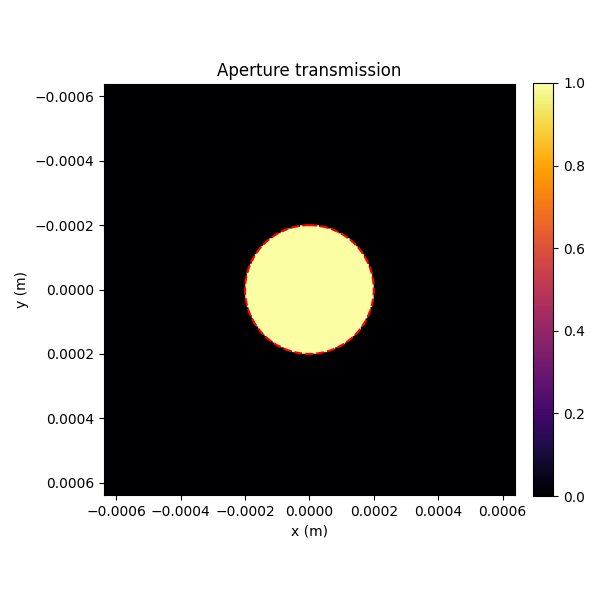

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
transmission = jax.vmap(aperture.log_transmission)(aperture_coordinates).reshape(det_aperture.shape)

im = ax.imshow(np.exp(transmission), origin="lower", extent=aperture_extent, cmap="inferno")
ax.set_title("Aperture transmission")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal")

# overlay nominal aperture radius
circ = plt.Circle((aperture.x0, aperture.y0), aperture.radius, color="red", fill=False, lw=1.5, ls='--')
ax.add_patch(circ)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [5]:
prop_to_aperture = z_aperture - jnp.asarray(rays_in.z)

rays_at_aperture = jax.vmap(fs)(rays_in, prop_to_aperture)
rays_after_aperture = jax.vmap(aperture)(rays_at_aperture)
prop_after_aperture = z_detector - jnp.asarray(rays_after_aperture.z)
rays_analytic_out = jax.vmap(fs)(rays_after_aperture, prop_after_aperture)


field_aperture = np.asarray(evaluate_gaussians_gpu_kernel_wrapper(rays_after_aperture, det_aperture))
field_analytic = np.asarray(evaluate_gaussians_gpu_kernel_wrapper(rays_analytic_out, det_output))

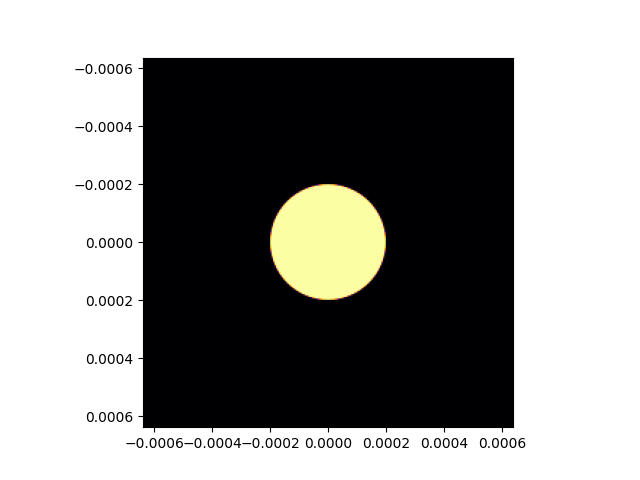

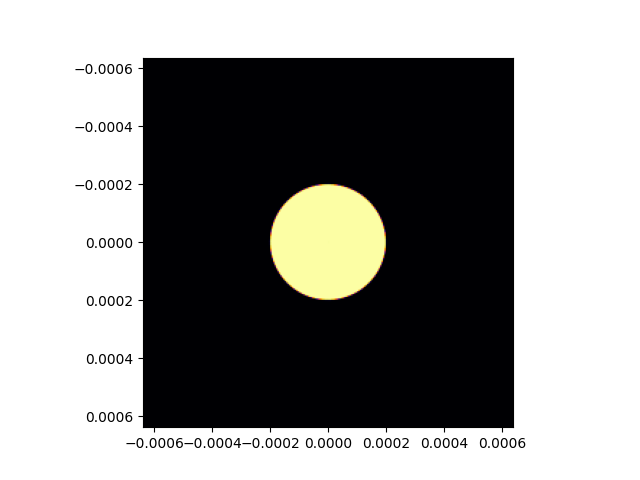

In [6]:
plt.figure()
plt.imshow(np.abs(field_aperture), extent=det_aperture.extent, origin='lower', cmap='inferno')

plt.figure()
plt.imshow(np.abs(field_analytic), extent=det_aperture.extent, origin='lower', cmap='inferno')



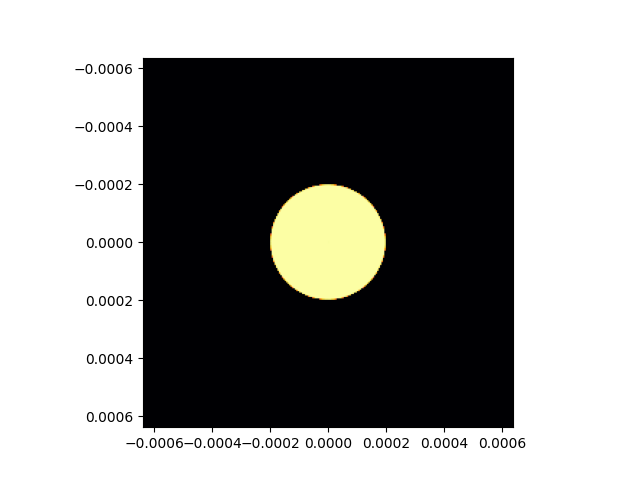

In [7]:
det_edge_x, det_edge_y = det_aperture.coords_1d
det_edge_x = np.asarray(det_edge_x)
det_edge_y = np.asarray(det_edge_y)
Y_ap, X_ap = np.meshgrid(det_edge_y, det_edge_x, indexing="ij")

coords = np.stack([X_ap.ravel(), Y_ap.ravel()], axis=-1)
log_trans = jax.vmap(aperture.log_transmission)(coords)
transmission = np.exp(np.asarray(log_trans)).reshape(shape)

field_after_aperture = field_aperture * transmission
field_fresnel = np.asarray(
    fresnel_fft_2d(X_ap, Y_ap, field_after_aperture, wavelength, prop_after_aperture[0])
)
plt.figure()
plt.imshow(np.abs(field_fresnel), extent=det_aperture.extent, origin='lower', cmap='inferno')

Amplitude max error (masked): 8.596e-06
Phase max error (masked): 1.319e-03 rad


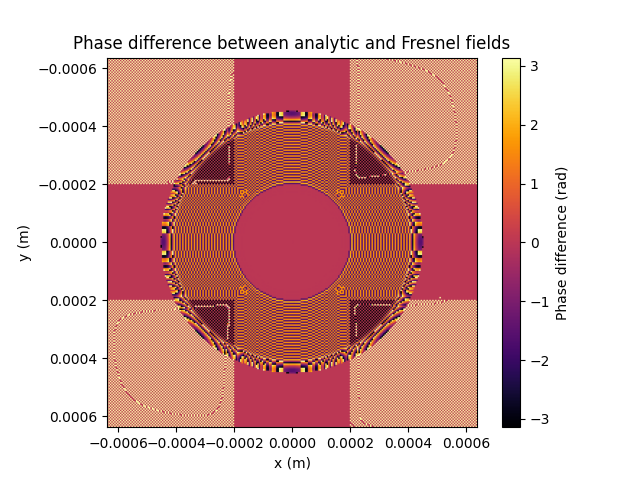

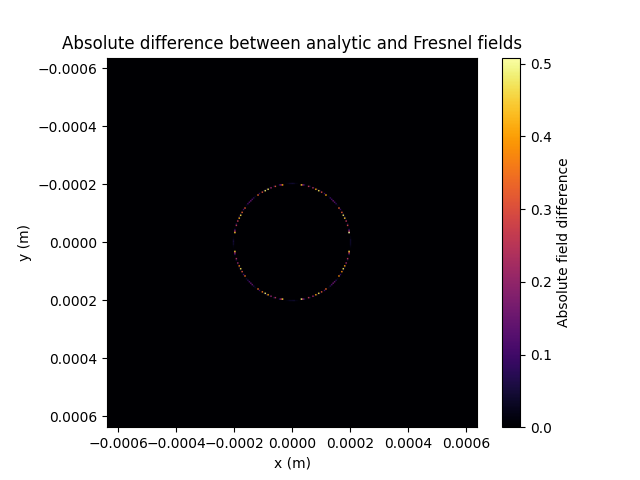

In [8]:
mask = np.abs(field_analytic) > 0.997
amp_error = np.max(np.abs(np.abs(field_analytic)[mask] - np.abs(field_fresnel)[mask]))
phase_diff = np.angle(field_analytic * np.conj(field_fresnel))
phase_error = np.max(np.abs(phase_diff)[mask])

plt.figure()
plt.imshow(phase_diff, extent=det_aperture.extent, origin='lower', cmap='inferno')
plt.colorbar(label='Phase difference (rad)')
plt.title('Phase difference between analytic and Fresnel fields')
plt.xlabel('x (m)')
plt.ylabel('y (m)')

plt.figure()
plt.imshow(np.abs(field_analytic - field_fresnel), extent=det_aperture.extent, origin='lower', cmap='inferno')
plt.colorbar(label='Absolute field difference')
plt.title('Absolute difference between analytic and Fresnel fields')
plt.xlabel('x (m)')
plt.ylabel('y (m)')

print(f"Amplitude max error (masked): {amp_error:.3e}")
print(f"Phase max error (masked): {phase_error:.3e} rad")

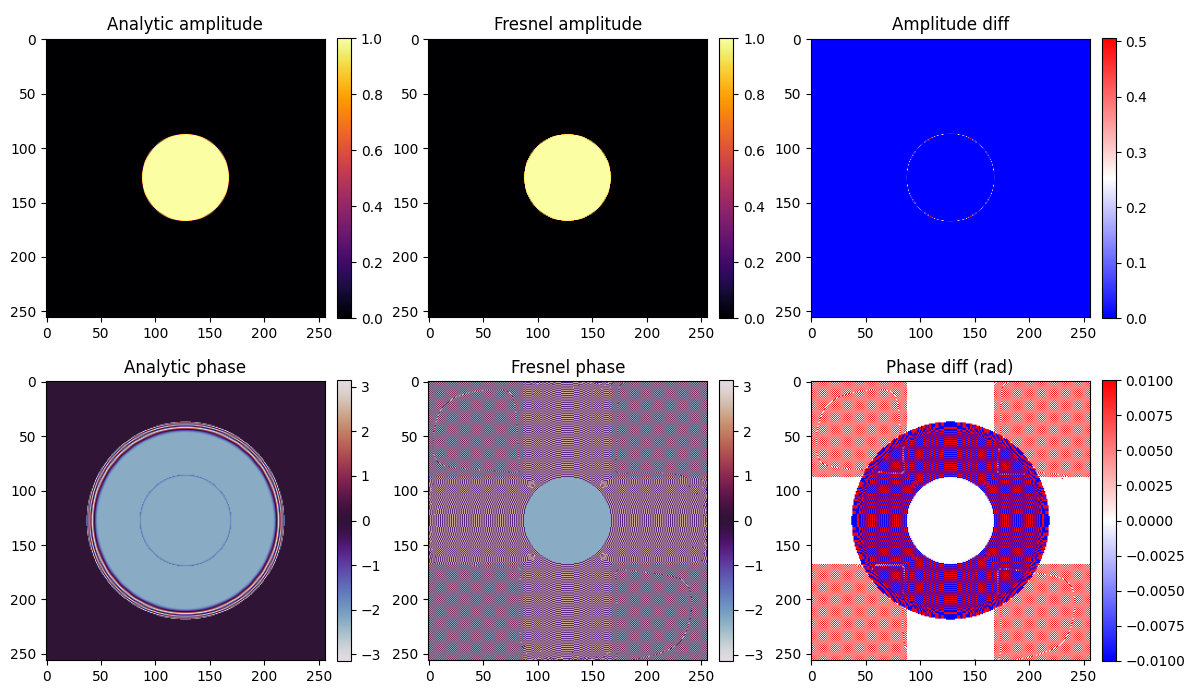

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
im0 = axes[0, 0].imshow(np.abs(field_analytic), cmap="inferno")
axes[0, 0].set_title("Analytic amplitude")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(np.abs(field_fresnel), cmap="inferno")
axes[0, 1].set_title("Fresnel amplitude")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(np.abs(field_analytic) - np.abs(field_fresnel), cmap="bwr")
axes[0, 2].set_title("Amplitude diff")
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

im3 = axes[1, 0].imshow(np.angle(field_analytic), cmap="twilight")
axes[1, 0].set_title("Analytic phase")
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(np.angle(field_fresnel), cmap="twilight")
axes[1, 1].set_title("Fresnel phase")
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(phase_diff, cmap="bwr", vmin=-0.01, vmax=0.01)
axes[1, 2].set_title("Phase diff (rad)")
fig.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()